# Homework 03: Python Fundamentals
Stage 03 — exploring and summarizing a dataset with NumPy and pandas.

## 1. NumPy Operations
Create an array, perform elementwise operations, and compare loop vs vectorized execution.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import time
from utils import get_summary_stats, loop_vs_vectorized_demo

arr = np.arange(1, 1_000_001)

# time a plain Python loop
start = time.time()
loop_result = [x ** 2 for x in arr]
loop_time = time.time() - start

# time the vectorized NumPy version
start = time.time()
vector_result = arr ** 2
vector_time = time.time() - start

print(f'Loop time: {loop_time:.4f}s')
print(f'Vectorized time: {vector_time:.4f}s')
print(f'Vectorized was {loop_time / vector_time:.1f}x faster')

Loop time: 0.4108s
Vectorized time: 0.0474s
Vectorized was 8.7x faster


In [2]:
# small-scale demo using the reusable utility function
small_arr = np.array([1, 2, 3, 4, 5])
loop_r, vec_r, match = loop_vs_vectorized_demo(small_arr)
print('Loop result:', loop_r)
print('Vectorized result:', vec_r)
print('Results match:', match)

Loop result: [ 1.  4.  9. 16. 25.]
Vectorized result: [ 1  4  9 16 25]
Results match: True


## 2. Dataset Loading
Load the provided CSV and inspect its structure.

In [3]:
df = pd.read_csv('../data/raw/starter_data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   category  30 non-null     str  
 1   value     30 non-null     int64
 2   date      30 non-null     str  
dtypes: int64(1), str(2)
memory usage: 852.0 bytes


In [4]:
df.head()

,category,value,date
0,B,17,2025-08-01
1,A,14,2025-08-02
2,B,84,2025-08-03
3,A,21,2025-08-04
4,B,81,2025-08-05


## 3. Summary Statistics
Describe numeric columns, then aggregate by category.

In [5]:
df.describe()

,value
count,30.000000
mean,42.666667
std,29.049700
min,6.000000
25%,18.250000
50%,30.000000
75%,71.000000
max,99.000000


In [6]:
# average and count of value per category
category_summary = df.groupby('category')['value'].agg(['mean', 'sum', 'count']).round(2)
category_summary

,mean,sum,count
category,,,
A,38.73,426,11
B,41.57,582,14
C,54.40,272,5


## 4. Save Outputs
Save the category summary to `data/processed/summary.csv`, plus a quick bonus plot.

In [7]:
category_summary.to_csv('../data/processed/summary.csv')
print('Saved summary to data/processed/summary.csv')

Saved summary to data/processed/summary.csv


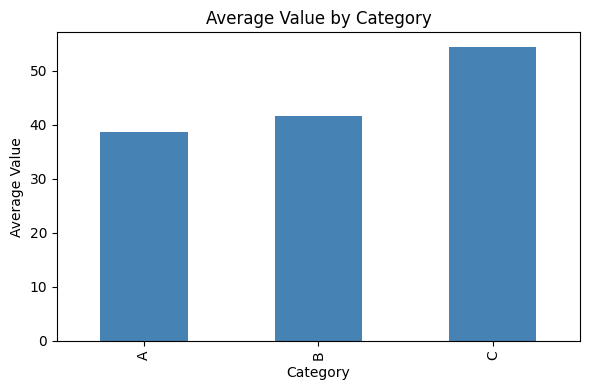

In [8]:
# bonus: simple bar chart of average value by category
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
category_summary['mean'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Average Value by Category')
ax.set_ylabel('Average Value')
ax.set_xlabel('Category')
plt.tight_layout()
plt.savefig('../data/processed/category_avg_value.png')
plt.show()

## 5. Reusable Functions
`get_summary_stats()` lives in `src/utils.py` and is imported above. Demo below shows it working both overall and grouped.

In [9]:
# overall summary stats using the utility function
get_summary_stats(df)

,value
count,30.000000
mean,42.666667
std,29.049700
min,6.000000
25%,18.250000
50%,30.000000
75%,71.000000
max,99.000000


In [10]:
# grouped summary stats using the same utility function
get_summary_stats(df, group_col='category')

value                                                      
         count       mean        std   min    25%   50%    75%   max
category                                                            
A         11.0  38.727273  28.053844  14.0  19.50  29.0  49.00  91.0
B         14.0  41.571429  30.901118   6.0  14.75  36.5  60.25  99.0
C          5.0  54.400000  28.780202  20.0  26.00  73.0  76.00  77.0